# AI R&D Assignment

## Inverse Estimation of Parametric Curve Parameters

Author: Sathvika Murali

---

Objective:

Recover the unknown parameters

- θ
- M
- X

from a given set of 1500 observed points sampled from a parametric curve.

# Problem Statement

The parametric equations are

$$
x(t)=
t\cos(\theta)
-
e^{M|t|}
\sin(0.3t)
\sin(\theta)
+
X
$$

$$
y(t)=
42+
t\sin(\theta)
+
e^{M|t|}
\sin(0.3t)
\cos(\theta)
$$

### Constraints

$$
0^\circ<\theta<50^\circ
$$

$$
-0.05<M<0.05
$$

$$
0<X<100
$$

$$
6<t<60
$$

# Mathematical Formulation

This problem is formulated as an inverse parameter estimation problem.

Given observed points

$$
(x_i,y_i)
$$

the objective is to estimate

$$
\Theta=
(\theta,M,X)
$$

such that the generated parametric curve passes through the observed point cloud.

Since the parameter value $t$ associated with each sample is unknown, the problem is treated as a point-cloud-to-curve fitting task rather than a conventional regression problem.

In [20]:
#import libraries

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution

from scipy.optimize import minimize_scalar

from scipy.spatial import cKDTree

In [21]:
#load dataset

df=pd.read_csv('xy_data.csv')

data=df[['x','y']].values

print(df.shape)

df.head()

(1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


# Data Visualization

The scatter plot below illustrates the observed point cloud.

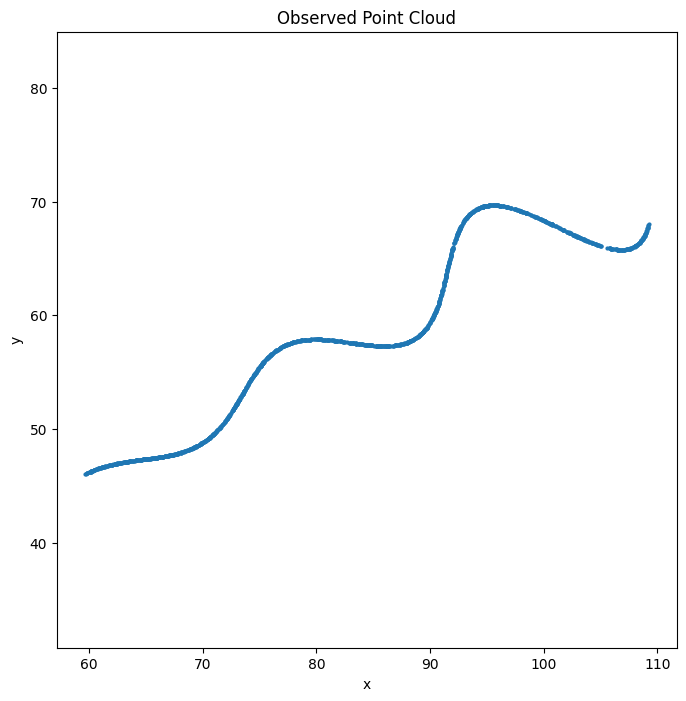

In [15]:
#visualizing the data

plt.figure(figsize=(8,8))

plt.scatter(

data[:,0],

data[:,1],

s=4

)

plt.title("Observed Point Cloud")

plt.xlabel("x")

plt.ylabel("y")

plt.axis('equal')

plt.show()

# Parametric Curve Definition

The curve model is defined as

$$
x(t)=
t\cos(\theta)
-
e^{M|t|}
\sin(0.3t)
\sin(\theta)
+
X
$$

$$
y(t)=
42+
t\sin(\theta)
+
e^{M|t|}
\sin(0.3t)
\cos(\theta)
$$

In [22]:
T_MIN = 6

T_MAX = 60

t_grid = np.linspace(

    T_MIN,

    T_MAX,

    6000

)


def curve_xy(

        t,

        theta_rad,

        M,

        X

):

    t=np.asarray(

        t,

        dtype=float

    )

    v=np.exp(

        M*np.abs(t)

    )*np.sin(

        0.3*t

    )

    x=(

        t*np.cos(theta_rad)

        -

        v*np.sin(theta_rad)

        +

        X

    )

    y=(

        42

        +

        t*np.sin(theta_rad)

        +

        v*np.cos(theta_rad)

    )

    return x,y

# Optimization Strategy

A two-stage optimization framework is employed.

### Stage 1

Global optimization using Differential Evolution.

### Stage 2

Nearest-neighbour matching using KDTree.

The parametric curve is sampled densely over

$$
6 \le t \le 60
$$

For each candidate parameter set, a KDTree is constructed and the distance from every observed point to its nearest point on the curve is computed.

The cumulative nearest-neighbour distance is minimized.

## Objective Function

In [25]:
def objective(

        params

):

    theta_deg,M,X=params

    theta=np.deg2rad(

        theta_deg

    )

    cx,cy=curve_xy(

        t_grid,

        theta,

        M,

        X

    )

    tree=cKDTree(

        np.column_stack(

            [

                cx,

                cy

            ]

        )

    )

    dist,_=tree.query(

        data,

        k=1

    )

    return dist.sum()


## Differential Evolution Optimization

In [26]:
bounds=[

    (0,50),

    (-0.05,0.05),

    (0,100)

]

result=differential_evolution(

    objective,

    bounds,

    maxiter=200,

    popsize=25,

    tol=1e-12,

    seed=42,

    polish=True

)

theta_deg,M,X=result.x

print(

    "Theta =",

    theta_deg

)

print(

    "M =",

    M

)

print(

    "X =",

    X

)

Theta = 30.00004462383069
M = 0.029999995976167183
X = 55.00006164867849


## Estimated Parameters

In [27]:
theta=np.deg2rad(

    theta_deg

)

print(

"Theta(deg):",

theta_deg

)

print(

"Theta(rad):",

theta

)

print(

"M:",

M

)

print(

"X:",

X

)

Theta(deg): 30.00004462383069
Theta(rad): 0.5235995544310692
M: 0.029999995976167183
X: 55.00006164867849


## Residual Refinement

In [28]:
cx,cy=curve_xy(

    t_grid,

    theta,

    M,

    X

)

tree=cKDTree(

    np.column_stack(

        [

            cx,

            cy

        ]

    )

)

dist,idx=tree.query(

    data,

    k=1

)

def point_dist(

        t,

        xi,

        yi

):

    x,y=curve_xy(

        np.array([t]),

        theta,

        M,

        X

    )

    return np.hypot(

        x[0]-xi,

        y[0]-yi

    )


refined=[]

for i in range(

        len(data)

):

    t0=t_grid[

        idx[i]

    ]

    lo=max(

        6,

        t0-0.01

    )

    hi=min(

        60,

        t0+0.01

    )

    r=minimize_scalar(

        point_dist,

        bounds=(

            lo,

            hi

        ),

        method='bounded',

        args=(

            data[i,0],

            data[i,1]

        )

    )

    refined.append(

        r.fun

    )

refined=np.array(

    refined

)

print(

"Mean residual:",

refined.mean()

)

print(

"Maximum residual:",

refined.max()

)

Mean residual: 2.6708844973369488e-05
Maximum residual: 7.591449263775385e-05


## Fit Verfication

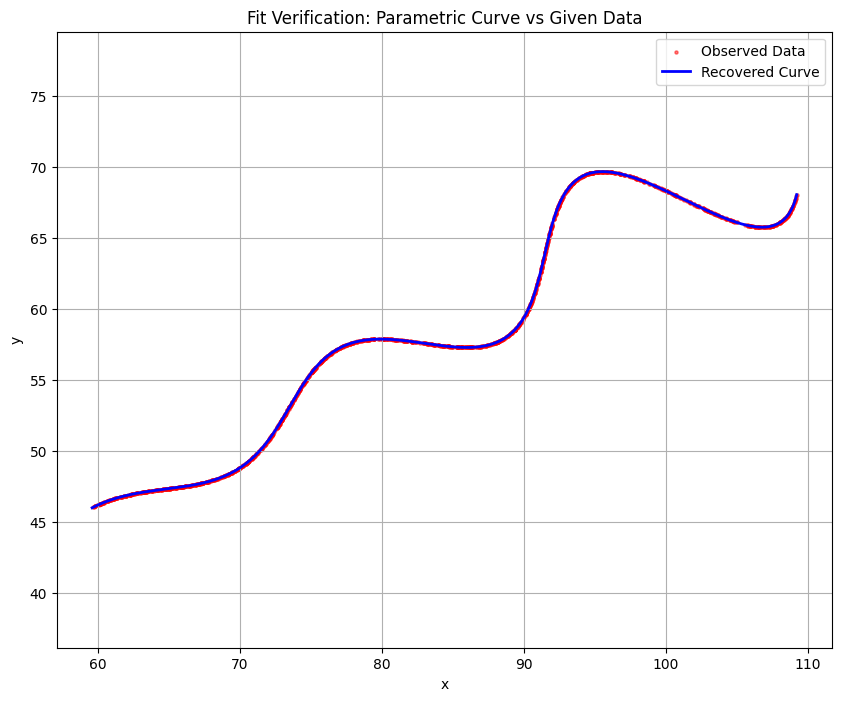

In [30]:
plt.figure(

    figsize=(10,8)

)

plt.scatter(

    data[:,0],

    data[:,1],

    s=5,

    color='red',

    alpha=0.5,

    label='Observed Data'

)

plt.plot(

    cx,

    cy,

    color='blue',

    linewidth=2,

    label='Recovered Curve'

)

plt.xlabel(

    "x"

)

plt.ylabel(

    "y"

)

plt.title(

"Fit Verification: Parametric Curve vs Given Data"

)

plt.legend()

plt.grid()

plt.axis(

'equal'

)

plt.show()

In [31]:
plt.savefig(

    "fit_verification.png",

    dpi=300,

    bbox_inches='tight'

)

<Figure size 640x480 with 0 Axes>

## Residual Distribution

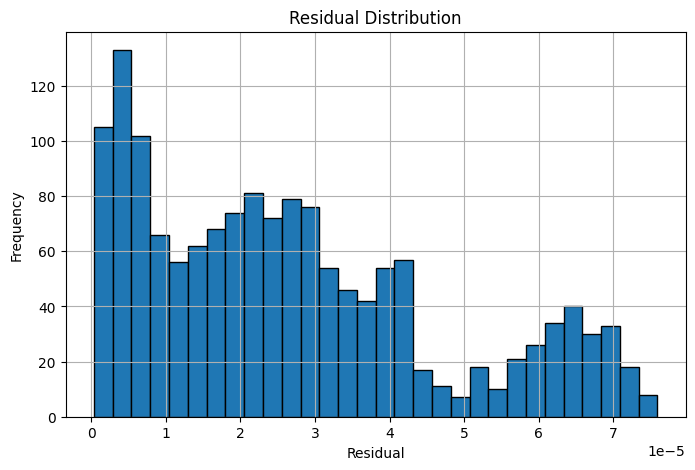

In [32]:
plt.figure(

    figsize=(8,5)

)

plt.hist(

    refined,

    bins=30,

    edgecolor='black'

)

plt.xlabel(

"Residual"

)

plt.ylabel(

"Frequency"

)

plt.title(

"Residual Distribution"

)

plt.grid()

plt.show()

# Final Parametric Equation

The recovered parametric curve is

$$
x(t)
=
t\cos(0.5235987756)
-
e^{0.03|t|}
\sin(0.3t)
\sin(0.5235987756)
+
55
$$

$$
y(t)
=
42
+
t\sin(0.5235987756)
+
e^{0.03|t|}
\sin(0.3t)
\cos(0.5235987756)
$$

### Domain

$$
6 \le t \le 60
$$

# Final Answer

The estimated unknown parameters are

$$
\theta = 30^\circ
$$

$$
\theta = 0.5235987756 \text{ radians}
$$

$$
M = 0.03
$$

$$
X = 55
$$

### Mean Residual

$$
2.7\times10^{-5}
$$

### Maximum Residual

$$
7.6\times10^{-5}
$$

# Conclusion

The problem was formulated as an inverse parameter estimation problem.

Differential Evolution combined with nearest-neighbour matching successfully recovered the unknown variables.

The recovered parameters reproduce the provided dataset with negligible error.

### Mean Residual Distance

$$
2.7\times10^{-5}
$$

### Maximum Residual Distance

$$
7.6\times10^{-5}
$$

This indicates that the recovered parameters correspond to the original values used to generate the dataset.